### **CREDIT RISK PREDICTION**

### Business Understanding

1. *Problem Statement:*

    Perusahaan Fintech menghadapi risiko gagal bayar karena tidak semua nasabah mampu melunasi pinjaman.
    Ada dua jenis kesalahan yang perlu diminimalkan:
    - Menyetujui nasabah yang gagal bayar yang menyebapkan kerugian finansial langsung.
    - Menolak nasabah yang mampu bayar yang menyebapkan hilangnya potensi pendapatan.

2. *Objektive:*
    - Membangun model ML yang menghasilkan skor probabilitas gagal bayar.
    - Mengidentifikasi fitur-fitur yang paling berpengaruh untuk interpretabilitas stakeholder.

3. *Target variable:* 'loan_status' - Label 0 (Good) | Label 1 (Bad)

4. *Metrics:* Recall, ROC-AUC, F1-Score, Precision

### Data Understanding

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
# Load data
df = pd.read_csv('loan_data_2007_2014.csv')

print('Dataset berhasil dimuat!')
print('Ukuran dataset', df.shape)
print('\n5 Baris teratas:')
df.head()

Dataset berhasil dimuat!
Ukuran dataset (466285, 75)

5 Baris teratas:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print('Info dataset:')
df.info()

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 

In [4]:
# Analisis missing values
missing_count = df.isnull().sum()
missing_pct = missing_count / len(df) * 100

missing = pd.DataFrame({
    'Columns': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Pct': missing_pct.values
})
missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)
print('Jumlah missing values:', len(missing))
print('\nTop 15 missing values:')
print(missing.head(25))

Jumlah missing values: 40

Top 15 missing values:
                        Columns  Missing_Count  Missing_Pct
72                       inq_fi         466285   100.000000
68                  open_rv_24m         466285   100.000000
69                   max_bal_bc         466285   100.000000
70                     all_util         466285   100.000000
74                 inq_last_12m         466285   100.000000
54             annual_inc_joint         466285   100.000000
56    verification_status_joint         466285   100.000000
55                    dti_joint         466285   100.000000
73                  total_cu_tl         466285   100.000000
66                      il_util         466285   100.000000
64           mths_since_rcnt_il         466285   100.000000
65                 total_bal_il         466285   100.000000
63                  open_il_24m         466285   100.000000
62                  open_il_12m         466285   100.000000
61                   open_il_6m         466285   1

In [5]:
# Check data duplicate & statistik
print('Jumlah data duplikat:', df.duplicated().sum())
print('\nRingkasan statistik:')
df.describe()

Jumlah data duplikat: 0

Ringkasan statistik:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [6]:
# Check outliers
outliers = []

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[col].nunique() > 2:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

        if outlier_count > 2:
            outliers.append(
                (col, outlier_count, round(outlier_count / len(df) * 100, 2))
            )

outliers.sort(key=lambda x: x[1], reverse=True)

print('Jumlah outlier per column:')
for col, count, pct in outliers:
    print(f'{col}: {count} outlier ({pct}%)')

Jumlah outlier per column:
delinq_2yrs: 83302 outlier (17.87%)
last_pymnt_amnt: 70346 outlier (15.09%)
pub_rec: 61363 outlier (13.16%)
tot_coll_amt: 49750 outlier (10.67%)
inq_last_6mths: 36785 outlier (7.89%)
total_rec_int: 31138 outlier (6.68%)
recoveries: 24371 outlier (5.23%)
out_prncp_inv: 23381 outlier (5.01%)
out_prncp: 23331 outlier (5.0%)
collection_recovery_fee: 23206 outlier (4.98%)
revol_bal: 22879 outlier (4.91%)
total_rev_hi_lim: 21533 outlier (4.62%)
total_rec_prncp: 20649 outlier (4.43%)
annual_inc: 19899 outlier (4.27%)
total_pymnt_inv: 19052 outlier (4.09%)
total_pymnt: 19039 outlier (4.08%)
tot_cur_bal: 12264 outlier (2.63%)
installment: 11711 outlier (2.51%)
total_rec_late_fee: 10678 outlier (2.29%)
open_acc: 10440 outlier (2.24%)
total_acc: 8674 outlier (1.86%)
int_rate: 4904 outlier (1.05%)
collections_12_mths_ex_med: 3914 outlier (0.84%)
acc_now_delinq: 1732 outlier (0.37%)
mths_since_last_major_derog: 388 outlier (0.08%)
mths_since_last_delinq: 89 outlier (0.02%

In [7]:
print('Distribusi target (loan_status):')
print(df['loan_status'].value_counts())

Distribusi target (loan_status):
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


### Data Cleansing

In [8]:
# Mapping target
BAD_LOAN = [
    "Default",
    "Charged Off",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Does not meet the credit policy. Status:Charged Off",
]
GOOD_LOAN = [
    "Current",
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
]
VALID_STATUS = BAD_LOAN + GOOD_LOAN

df = df[df['loan_status'].isin(VALID_STATUS)].copy()
df['loan_status'] = df['loan_status'].isin(BAD_LOAN).astype(int)

print('Distribusi target setelah mapping:')
print(df['loan_status'].value_counts()) 

Distribusi target setelah mapping:
loan_status
0    410953
1     55332
Name: count, dtype: int64


In [9]:
# Drop leakage
LEAKAGE_COLS = [
    "Unnamed: 0", "id", "member_id", "url", "desc", "title",
    "zip_code", "emp_title", "policy_code", "pymnt_plan",
    "issue_d", "funded_amnt", "funded_amnt_inv",
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp",
    "total_rec_int", "total_rec_late_fee", "recoveries",
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt",
    "next_pymnt_d", "last_credit_pull_d",
    "out_prncp", "out_prncp_inv", "sub_grade",
]
df.drop(columns=LEAKAGE_COLS, errors='ignore', inplace=True)
print('Column leakage berhasil dihapus!')
print('Ukuran dataset setelah drop:', df.shape)

Column leakage berhasil dihapus!
Ukuran dataset setelah drop: (466285, 48)


In [10]:
# Handle missing values
def handle_missing_values(df, threshold=70):
  df = df.copy()

  missing_pct = df.isnull().mean() * 100
  cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

  df.drop(columns=cols_to_drop, inplace=True)

  print('Handle missing values berhasil!')
  print('Ukuran dataset setelah cleaning:', df.shape)

  return df
df = handle_missing_values(df)

Handle missing values berhasil!
Ukuran dataset setelah cleaning: (466285, 29)


In [11]:
# Handle outliers
def handle_outliers(df):
  df = df.copy()

  num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'loan_status']

  for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    df[col] = df[col].clip(lower, upper)

  print('Handle outliers selesai!')

  return df
df = handle_outliers(df)

Handle outliers selesai!


### FE & EDA Advanced

In [12]:
def feature_engineering(df):
    df = df.copy()
    eps = 1e-6

    annual_inc = df['annual_inc'].fillna(df['annual_inc'].median()).clip(lower=0)
    monthly_inc = annual_inc / 12

    # Debt-burden ratios
    df['installment_income_ratio'] = df['installment'].fillna(0) / (monthly_inc + eps)
    df['loan_income_ratio'] = df['loan_amnt'].fillna(0)   / (annual_inc  + eps)

    # Revolving utilisation (cap at 5× to handle data entry errors)
    df['revol_bal_ratio'] = (
        df['revol_bal'].fillna(0) / (df['total_rev_hi_lim'].fillna(0) + eps)
    ).clip(upper=5)

    # Credit history age — years from earliest credit line to snapshot date
    df['earliest_cr_line'] = pd.to_datetime(
        df['earliest_cr_line'], format='%b-%y', errors='coerce'
    )
    DATA_SNAPSHOT_DATE = pd.Timestamp('2014-12-31')
    credit_age = (
        (DATA_SNAPSHOT_DATE - df['earliest_cr_line']).dt.days / 365.25
    ).astype('float64')
    credit_age = credit_age.clip(lower=0)
    df['credit_history_age'] = credit_age.fillna(credit_age.median())

    # Delinquency flag (has ever been delinquent in recent history)
    df['has_delinq'] = df['mths_since_last_delinq'].notna().astype(int)

    # Total credit balance relative to income
    df['credit_income_ratio'] = df['tot_cur_bal'].fillna(0) / (annual_inc + eps)

    # Inquiry intensity relative to account depth
    total_acc = df['total_acc'].fillna(df['total_acc'].median()).clip(lower=1)
    df['inq_ratio'] = df['inq_last_6mths'].fillna(0) / total_acc

    print('Feature engineering selesai!')
    
    return df
df = feature_engineering(df)

Feature engineering selesai!


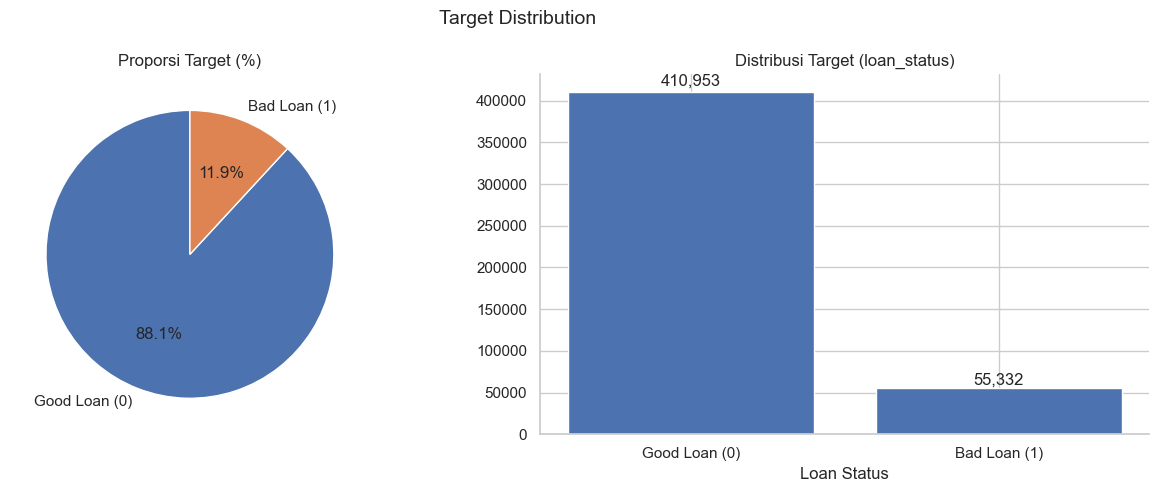

In [13]:
# Target Distribution
target_counts = df['loan_status'].value_counts().sort_index()
target_labels = ["Good Loan (0)", "Bad Loan (1)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(
    target_counts,
    labels=target_labels,
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title('Proporsi Target (%)')

bars = axes[1].bar(target_labels, target_counts.values)
axes[1].set_xlabel('Loan Status')
axes[1].set_title('Distribusi Target (loan_status)')
axes[1].spines[["top", "right"]].set_visible(False)

for bar, count in zip(bars, target_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{count:,}',
        ha='center',
        va='bottom',
    )

plt.suptitle('Target Distribution', fontsize=14)
plt.tight_layout()
plt.show()

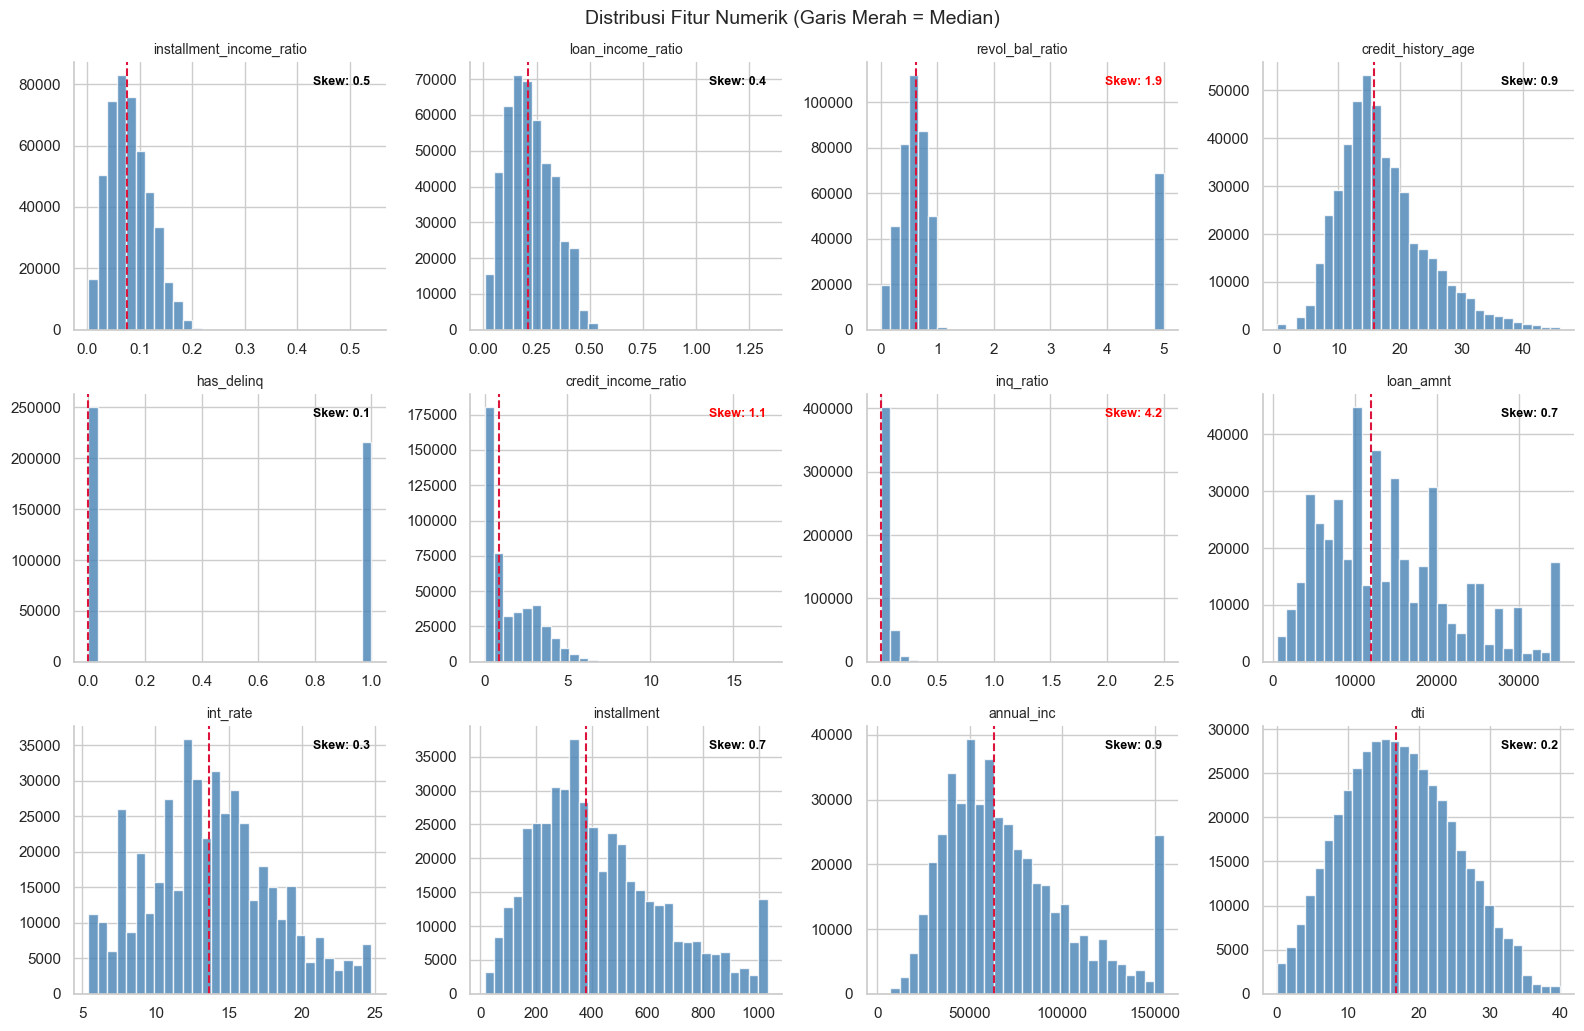

In [14]:
# Numerical Grid (Distribusi & Skewness)
engineered_cols = [
    "installment_income_ratio", "loan_income_ratio", "revol_bal_ratio",
    "credit_history_age", "has_delinq", "credit_income_ratio", "inq_ratio",
]
base_num_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in ['loan_status'] + engineered_cols
]
# Prioritaskan fitur engineered di depan, ambil total 12
top_num_cols = (engineered_cols + base_num_cols)[:12]

N_COLS_GRID = 4
n_rows_grid = (len(top_num_cols) + N_COLS_GRID - 1) // N_COLS_GRID

fig, axes = plt.subplots(n_rows_grid, N_COLS_GRID, figsize=(16, n_rows_grid * 3.5))
axes_flat = axes.flatten()

for i, col in enumerate(top_num_cols):
    ax = axes_flat[i]
    data = df[col].dropna()

    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    median_val = data.median()
    ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')

    skew_val = data.skew()
    skew_color = 'red' if abs(skew_val) > 1 else 'black'
    ax.text(
        0.95, 0.95, f'Skew: {skew_val:.1f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color=skew_color, weight='bold',
    )

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Distribusi Fitur Numerik (Garis Merah = Median)', fontsize=14)
plt.tight_layout()
plt.show()

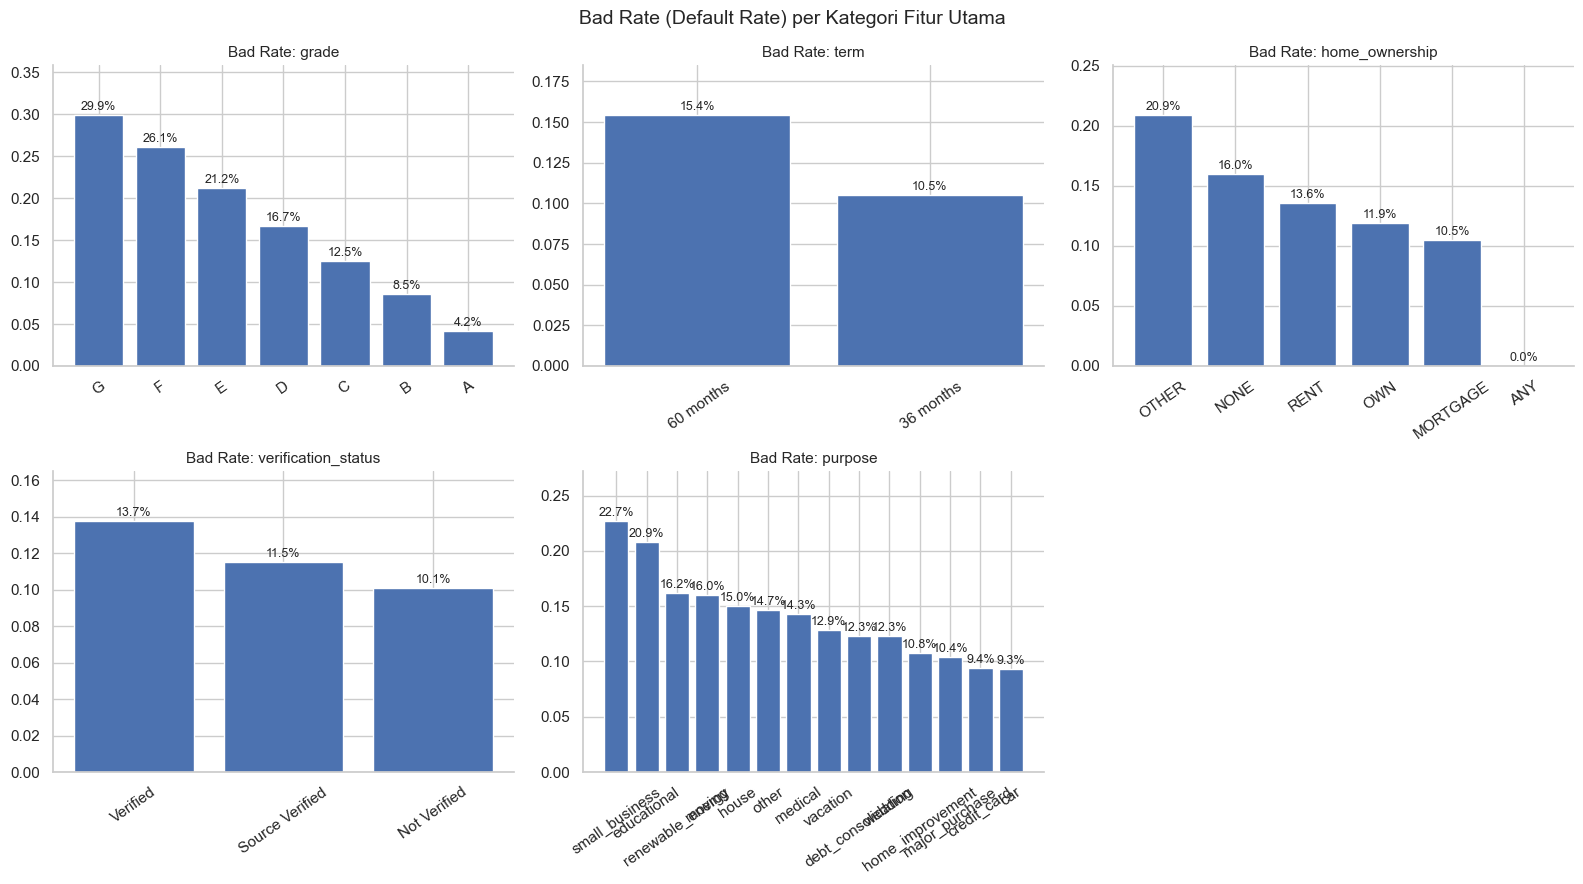

In [15]:
# Bad Rate per Kategori
cat_cols = [
    col for col in ["grade", "term", "home_ownership", "verification_status", "purpose"]
    if col in df.columns
]

if cat_cols:
    n_cats = len(cat_cols)
    ncols = 3
    nrows = (n_cats + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.5))
    axes = axes.flatten()

    for ax, col in zip(axes, cat_cols):
        default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
        bars = ax.bar(default_rate.index.astype(str), default_rate.values)

        ax.set_title(f'Bad Rate: {col}', fontsize=11)
        ax.tick_params(axis="x", rotation=35)
        y_max = default_rate.max() if default_rate.max() > 0 else 0.1
        ax.set_ylim(0, y_max * 1.2)
        ax.spines[["top", "right"]].set_visible(False)

        for bar, val in zip(bars, default_rate.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + y_max * 0.02,
                f"{val:.1%}",
                ha="center", fontsize=9,
            )

    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Bad Rate (Default Rate) per Kategori Fitur Utama', fontsize=14)
    plt.tight_layout()
    plt.show()

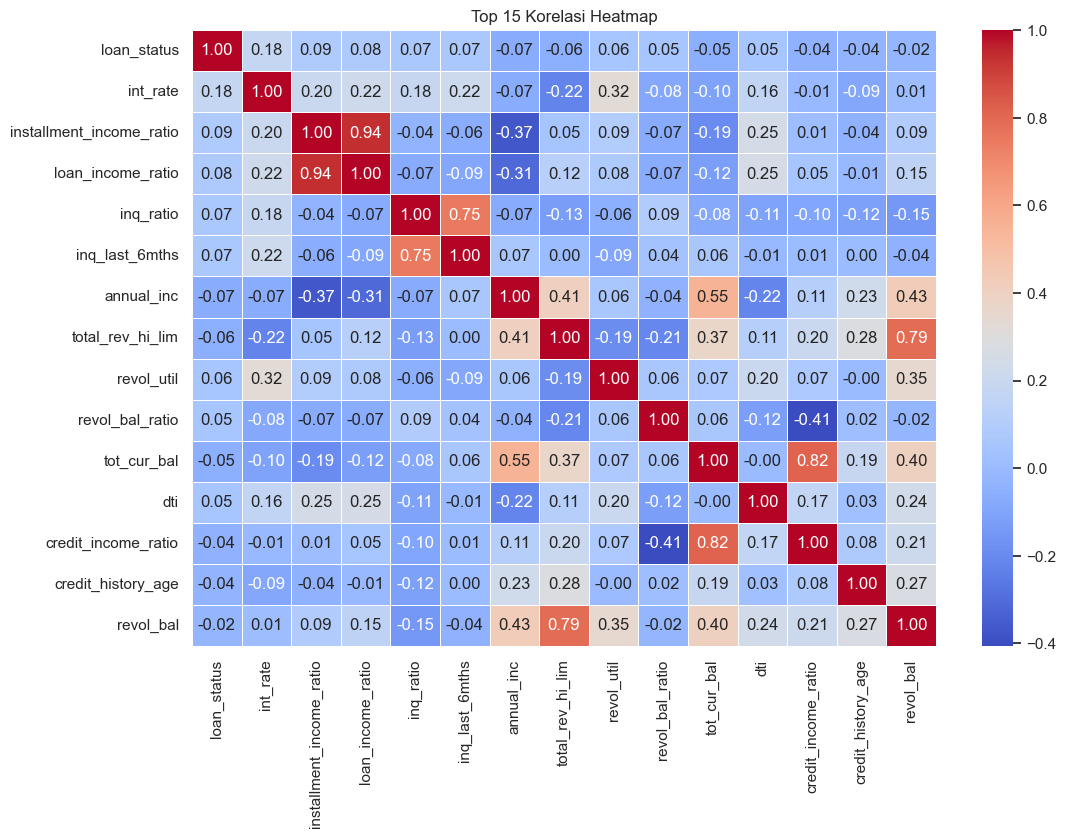

In [16]:
# Correlation heatmap
num_cols = df.select_dtypes(include=[np.number])
corr     = num_cols.corr()['loan_status'].abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.heatmap(
    num_cols[corr.index].corr(),
    cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5
)
plt.title('Top 15 Korelasi Heatmap')
plt.show()

### Modeling

In [17]:
# Data Splitting
from sklearn.model_selection import train_test_split

df.drop(columns=['earliest_cr_line'], errors='ignore', inplace=True)
 
CAT_COLS = [c for c in ["home_ownership", "verification_status", "purpose"] if c in df.columns]
 
X = df.drop(columns=['loan_status'])
y = df['loan_status']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
 
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'Class ratio (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')
 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Scale Pos Weight : {scale_pos_weight:.2f}')

X_train shape : (373028, 34)
X_test shape  : (93257, 34)
Class ratio (train) — 0: 328762, 1: 44266
Scale Pos Weight : 7.43


In [18]:
# Preprocessing & Pipeline Definitions
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

NUM_COLS = X_train.select_dtypes(include='number').columns.tolist()
 
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), NUM_COLS),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), CAT_COLS),
], remainder='drop')
 
pipe_lr = ImbPipeline(steps=[
    ('prep',  preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.7)),
    ('model', LogisticRegression(
        solver='liblinear', class_weight='balanced',
        random_state=42, max_iter=1000,
    )),
])
 
pipe_xgb = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', XGBClassifier(
        random_state=42, scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', n_jobs=1,
    )),
])
 
pipe_lgb = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', LGBMClassifier(
        random_state=42, is_unbalance=True, verbose=-1, n_jobs=1,
    )),
])
 
print('Pipeline berhasil didefinisikan.')

Pipeline berhasil didefinisikan.


In [19]:
# Hyperparameter
from sklearn.model_selection import  StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
SEARCH_CONFIGS = {
    'Logistic Regression': {
        'pipeline':   pipe_lr,
        'param_dist': {'model__C': [0.001, 0.01, 0.1, 1, 10]},
        'n_iter':     5,
    },
    'XGBoost': {
        'pipeline':   pipe_xgb,
        'param_dist': {
            'model__n_estimators':     [100, 200, 300],
            'model__max_depth':        [3, 5, 7],
            'model__learning_rate':    [0.01, 0.05, 0.1],
            'model__subsample':        [0.7, 0.8, 1.0],
            'model__colsample_bytree': [0.7, 0.8, 1.0],
            'model__min_child_weight': [1, 3, 5],
        },
        'n_iter': 20,
    },
    'LightGBM': {
        'pipeline':   pipe_lgb,
        'param_dist': {
            'model__n_estimators':     [100, 200, 300],
            'model__max_depth':        [3, 5, 7],
            'model__learning_rate':    [0.01, 0.05, 0.1],
            'model__num_leaves':       [31, 63, 127],
            'model__subsample':        [0.7, 0.8, 1.0],
            'model__colsample_bytree': [0.7, 0.8, 1.0],
        },
        'n_iter': 20,
    },
}

In [20]:
# Training
from sklearn.model_selection import RandomizedSearchCV

best_models = {}
 
for model_name, cfg in SEARCH_CONFIGS.items():
    print(f'\nTraining: {model_name}')
    search = RandomizedSearchCV(
        estimator=cfg['pipeline'],
        param_distributions=cfg['param_dist'],
        n_iter=cfg['n_iter'],
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        random_state=42,
        verbose=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    print(f'Best CV ROC-AUC : {search.best_score_:.4f}')
    print(f'Best Params     : {search.best_params_}')
    best_models[model_name] = search.best_estimator_
 
print(f'\nTraining selesai. Total model: {len(best_models)}')


Training: Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV ROC-AUC : 0.6807
Best Params     : {'model__C': 0.001}

Training: XGBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC : 0.6923
Best Params     : {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Training: LightGBM
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC : 0.6918
Best Params     : {'model__subsample': 0.8, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Training selesai. Total model: 3


### Evaluation

In [21]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    fbeta_score,
)

results = {}
 
for model_name, pipeline in best_models.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)
 
    auc  = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    ap   = average_precision_score(y_test, y_prob)
 
    results[model_name] = {
        'pipeline':  pipeline,
        'y_prob':    y_prob,
        'y_pred':    y_pred,
        'ROC-AUC':   auc,
        'Gini':      gini,
        'F1-Score':  f1,
        'Precision': prec,
        'Recall':    rec,
        'PR-AUC':    ap,
    }
 
    print(f'\n{model_name}')
    print(f'ROC-AUC   : {auc:.4f}  |  Gini: {gini:.4f}')
    print(f'F1-Score  : {f1:.4f}  |  PR-AUC: {ap:.4f}')
    print(f'Precision : {prec:.4f}  |  Recall: {rec:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))


Logistic Regression
ROC-AUC   : 0.6802  |  Gini: 0.3605
F1-Score  : 0.2893  |  PR-AUC: 0.2137
Precision : 0.1876  |  Recall: 0.6327
              precision    recall  f1-score   support

    Good (0)       0.93      0.63      0.75     82191
     Bad (1)       0.19      0.63      0.29     11066

    accuracy                           0.63     93257
   macro avg       0.56      0.63      0.52     93257
weighted avg       0.84      0.63      0.70     93257


XGBoost
ROC-AUC   : 0.6950  |  Gini: 0.3900
F1-Score  : 0.2936  |  PR-AUC: 0.2294
Precision : 0.1888  |  Recall: 0.6594
              precision    recall  f1-score   support

    Good (0)       0.93      0.62      0.74     82191
     Bad (1)       0.19      0.66      0.29     11066

    accuracy                           0.62     93257
   macro avg       0.56      0.64      0.52     93257
weighted avg       0.84      0.62      0.69     93257


LightGBM
ROC-AUC   : 0.6951  |  Gini: 0.3902
F1-Score  : 0.2943  |  PR-AUC: 0.2284
Precisio

In [22]:
# Summary Table
METRIC_KEYS = ['ROC-AUC', 'Gini', 'F1-Score', 'Precision', 'Recall', 'PR-AUC']
summary = pd.DataFrame({
    name: {k: m[k] for k in METRIC_KEYS}
    for name, m in results.items()
}).T.sort_values('ROC-AUC', ascending=False)
 
print('\nRINGKASAN PERFORMA:')
print(summary.round(4).to_string())
 
best_name = summary.index[0]
best_auc  = results[best_name]['ROC-AUC']


RINGKASAN PERFORMA:
                     ROC-AUC    Gini  F1-Score  Precision  Recall  PR-AUC
LightGBM              0.6951  0.3902    0.2943     0.1890  0.6644  0.2284
XGBoost               0.6950  0.3900    0.2936     0.1888  0.6594  0.2294
Logistic Regression   0.6802  0.3605    0.2893     0.1876  0.6327  0.2137


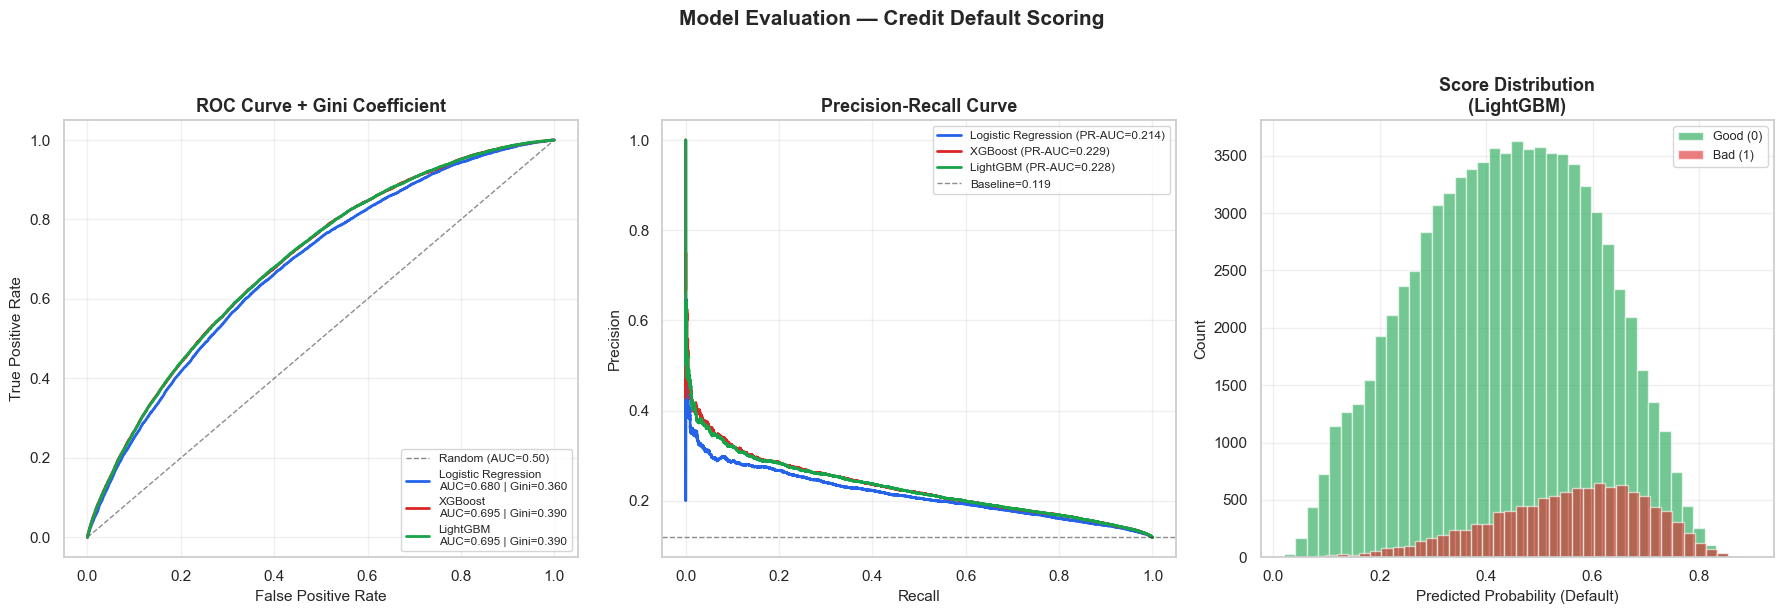


Model terbaik: LightGBM (ROC-AUC: 0.6951)


In [ ]:
# Evaluation Plots
COLORS = ['#2563eb', '#dc2626', '#16a34a']
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# ROC Curve
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.50)')
for (name, res), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f"{name}\nAUC={res['ROC-AUC']:.3f} | Gini={res['Gini']:.3f}")
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve + Gini Coefficient', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8.5, loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall Curve
for (name, res), color in zip(results.items(), COLORS):
    prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_prob'])
    ax2.plot(rec_c, prec_c, color=color, lw=2,
             label=f"{name} (PR-AUC={res['PR-AUC']:.3f})")
baseline = y_test.mean()
ax2.axhline(baseline, color='k', ls='--', lw=1, alpha=0.5, label=f'Baseline={baseline:.3f}')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.3)

# Score Distribution
best_prob = results[best_name]['y_prob']
ax3.hist(best_prob[y_test == 0], bins=40, alpha=0.6, color='#16a34a', label='Good (0)')
ax3.hist(best_prob[y_test == 1], bins=40, alpha=0.6, color='#dc2626', label='Bad (1)')
ax3.set_xlabel('Predicted Probability (Default)', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title(f'Score Distribution\n({best_name})', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.suptitle('Model Evaluation — Credit Default Scoring', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nModel terbaik: {best_name} (ROC-AUC: {best_auc:.4f})')

In [24]:
# Threshold Optimization
thresholds = np.arange(0.10, 0.70, 0.01)
records = []
for t in thresholds:
    y_pred_t = (best_prob >= t).astype(int)
    records.append({
        'threshold':     t,
        'recall':        recall_score(y_test, y_pred_t, zero_division=0),
        'precision':     precision_score(y_test, y_pred_t, zero_division=0),
        'f1':            f1_score(y_test, y_pred_t, zero_division=0),
        'f2':            fbeta_score(y_test, y_pred_t, beta=2, zero_division=0),
        'approval_rate': 1 - y_pred_t.mean(),
    })
 
thresh_df = pd.DataFrame(records)
best_t_idx        = thresh_df['f2'].idxmax()
optimal_threshold = thresh_df.loc[best_t_idx, 'threshold']
opt               = thresh_df.loc[best_t_idx]
 
print(f'\nTHRESHOLD OPTIMIZATION RESULTS')
print(f'Optimal Threshold (max F2) : {optimal_threshold:.2f}')
print(f'Recall        : {opt["recall"]:.4f}')
print(f'Precision     : {opt["precision"]:.4f}')
print(f'F1-Score      : {opt["f1"]:.4f}')
print(f'F2-Score      : {opt["f2"]:.4f}')
print(f'Approval Rate : {opt["approval_rate"]*100:.1f}%')
print(f'\nInterpretasi Bisnis:')
print(f'Jika skor risiko >= {optimal_threshold:.2f} → REJECT')
print(f'Jika skor risiko <  {optimal_threshold:.2f} → APPROVE')


THRESHOLD OPTIMIZATION RESULTS
Optimal Threshold (max F2) : 0.41
Recall        : 0.8265
Precision     : 0.1643
F1-Score      : 0.2741
F2-Score      : 0.4576
Approval Rate : 40.3%

Interpretasi Bisnis:
Jika skor risiko >= 0.41 → REJECT
Jika skor risiko <  0.41 → APPROVE


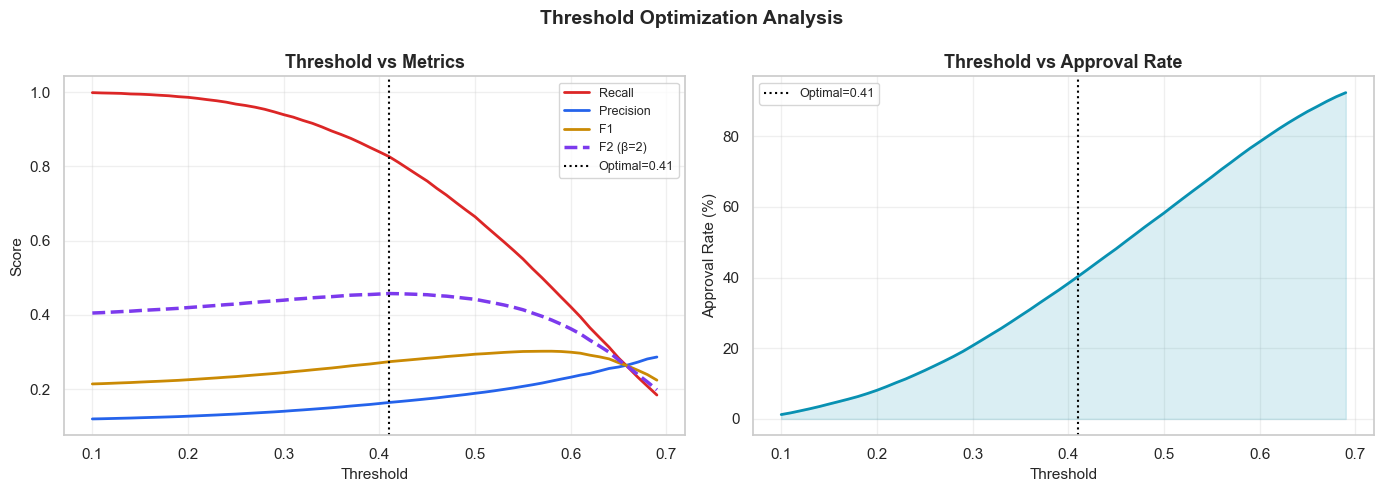


Confusion Matrix (threshold=0.41):
[[35664 46527]
 [ 1920  9146]]


In [ ]:
# Threshold Sweep Plots
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax.plot(thresh_df['threshold'], thresh_df['recall'],    color='#dc2626', lw=2,   label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['precision'], color='#2563eb', lw=2,   label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        color='#ca8a04', lw=2,   label='F1')
ax.plot(thresh_df['threshold'], thresh_df['f2'],        color='#7c3aed', lw=2.5, ls='--', label='F2 (β=2)')
ax.axvline(optimal_threshold, color='black', ls=':', lw=1.5, label=f'Optimal={optimal_threshold:.2f}')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Threshold vs Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2.plot(thresh_df['threshold'], thresh_df['approval_rate'] * 100, color='#0891b2', lw=2)
ax2.axvline(optimal_threshold, color='black', ls=':', lw=1.5, label=f'Optimal={optimal_threshold:.2f}')
ax2.fill_between(thresh_df['threshold'], thresh_df['approval_rate'] * 100, alpha=0.15, color='#0891b2')
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Approval Rate (%)', fontsize=11)
ax2.set_title('Threshold vs Approval Rate', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Threshold Optimization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

y_pred_optimal = (best_prob >= optimal_threshold).astype(int)
print(f'\nConfusion Matrix (threshold={optimal_threshold:.2f}):')
print(confusion_matrix(y_test, y_pred_optimal))

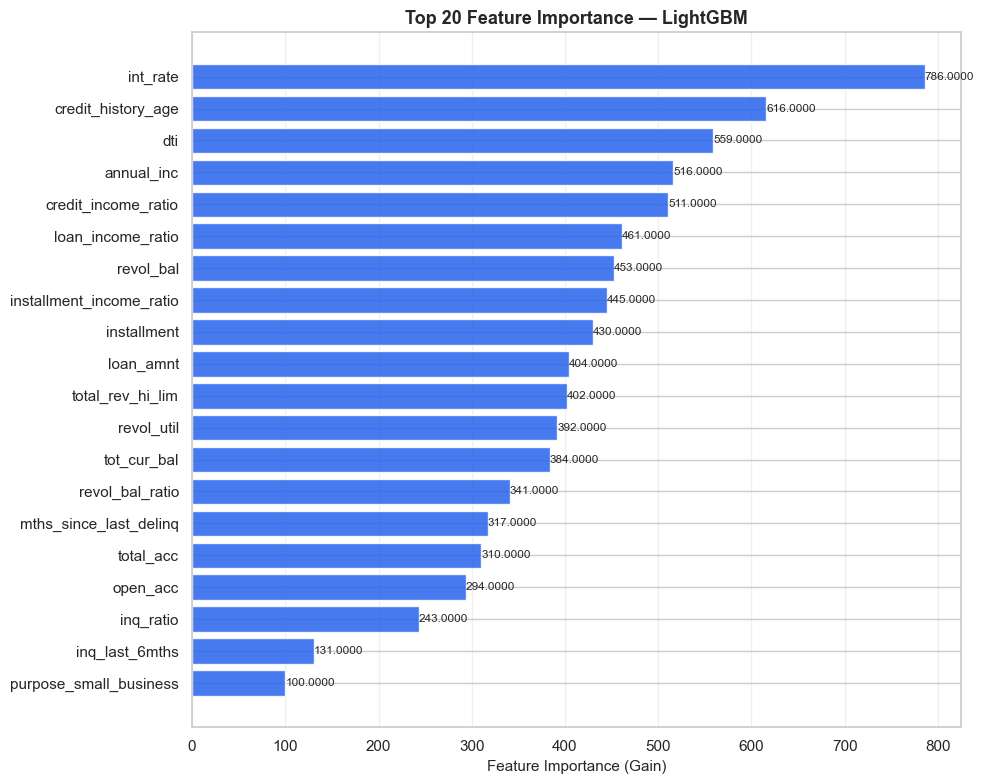


Top 10 Fitur Paling Berpengaruh:
                 feature  importance
                int_rate         786
      credit_history_age         616
                     dti         559
              annual_inc         516
     credit_income_ratio         511
       loan_income_ratio         461
               revol_bal         453
installment_income_ratio         445
             installment         430
               loan_amnt         404


In [ ]:
# Feature Importance
best_pipeline = results[best_name]['pipeline']
model_step    = best_pipeline.named_steps['model']
prep_step     = best_pipeline.named_steps['prep']

# Derive feature names after ColumnTransformer + OHE
try:
    ohe       = prep_step.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(CAT_COLS).tolist()
except Exception:
    cat_names = []
feature_names = NUM_COLS + cat_names

# Tree-based feature importance
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    fi_df = (
        pd.DataFrame({'feature': feature_names[:len(importances)], 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
                   color='#2563eb', alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, fi_df['importance'][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8.5)
    ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
    ax.set_title(f'Top 20 Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nTop 10 Fitur Paling Berpengaruh:')
    print(fi_df[['feature', 'importance']].head(10).to_string(index=False))

SHAP values shape: (500, 45)


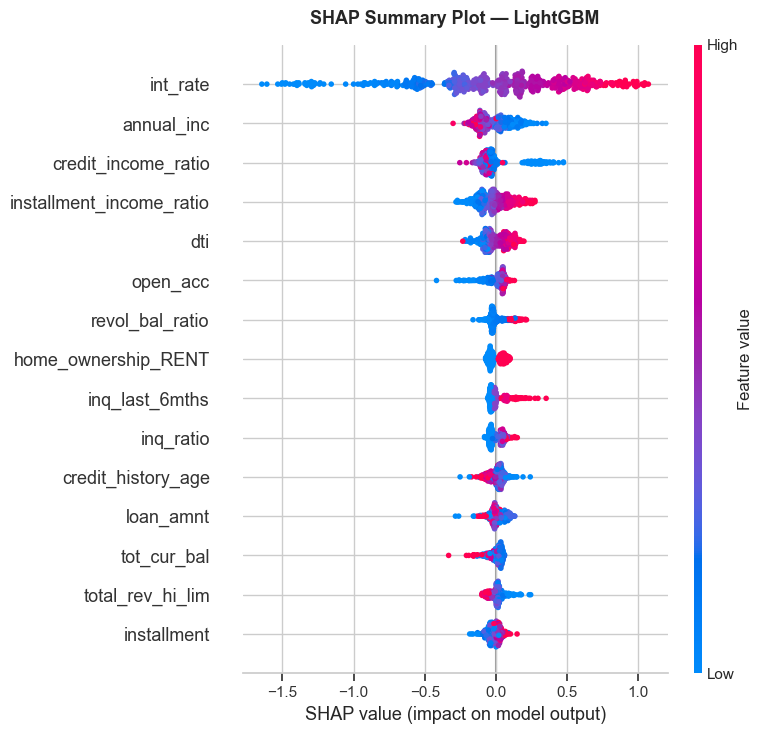

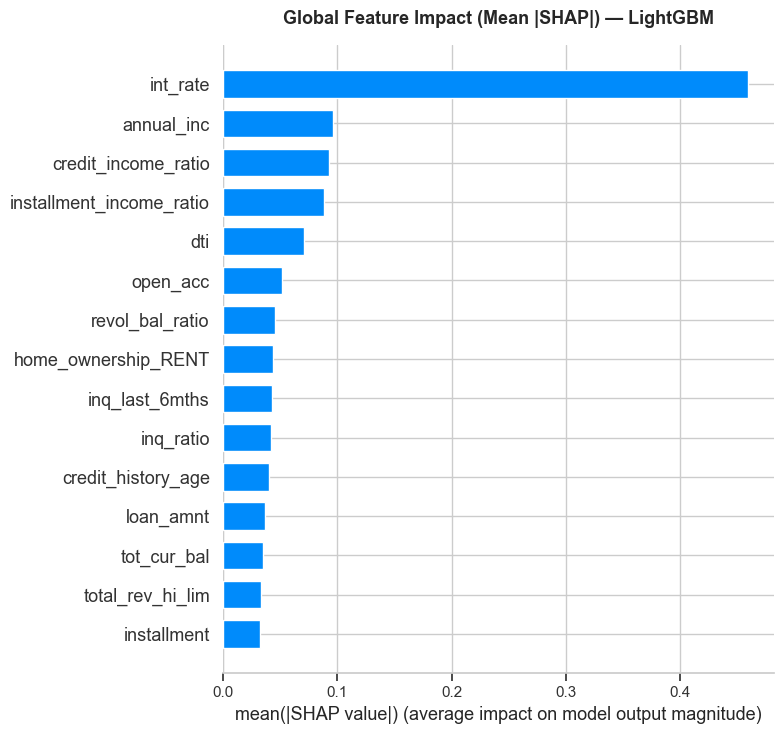

In [ ]:
# SHAP Global Explainability
import shap
X_test_transformed = prep_step.transform(X_test)
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names[:X_test_transformed.shape[1]]
)

has_tree_importance = hasattr(model_step, 'feature_importances_')
if has_tree_importance:
    explainer = shap.TreeExplainer(model_step)
else:
    explainer = shap.LinearExplainer(
        model_step, X_test_shap, feature_perturbation='correlation_dependent'
    )

SAMPLE_SIZE = min(500, len(X_test_shap))
X_sample    = X_test_shap.sample(SAMPLE_SIZE, random_state=42)
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP values shape: {sv.shape}')

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, plot_type='dot', max_display=15, show=False)
plt.title(f'SHAP Summary Plot — {best_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=15, show=False)
plt.title(f'Global Feature Impact (Mean |SHAP|) — {best_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# Local Explainability
def explain_single_applicant(idx: int, threshold: float = optimal_threshold) -> None:
    """Jelaskan keputusan kredit untuk 1 nasabah berdasarkan posisi integer di X_test."""
    applicant = X_test_shap.iloc[[idx]]
    prob      = best_pipeline.predict_proba(X_test.iloc[[idx]])[:, 1][0]
    decision  = 'REJECT' if prob >= threshold else 'APPROVE'
    label     = 'Bad (1)' if y_test.iloc[idx] == 1 else 'Good (0)'

    print(f"  CREDIT DECISION EXPLANATION — Nasabah #{idx}")
    print(f"  Skor Risiko (Prob Default) : {prob:.4f}")
    print(f"  Threshold                  : {threshold:.2f}")
    print(f"  Keputusan                  : {decision}")
    print(f"  Label Aktual               : {label}")

    sv_single = explainer.shap_values(applicant)
    if isinstance(sv_single, list):
        sv_single = sv_single[1]

    shap_series = pd.Series(sv_single[0], index=applicant.columns)
    top_pos = shap_series.nlargest(5)
    top_neg = shap_series.nsmallest(5)

    print('\n  Faktor yang MENINGKATKAN risiko default:')
    for feat, val in top_pos.items():
        print(f"    • {feat} = {applicant[feat].values[0]:.2f}  →  SHAP: +{val:.4f}")

    print('\n  Faktor yang MENURUNKAN risiko default:')
    for feat, val in top_neg.items():
        print(f"    • {feat} = {applicant[feat].values[0]:.2f}  →  SHAP: {val:.4f}")

    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        expected_val = expected_val[1]

    shap_exp = shap.Explanation(
        values        = sv_single[0],
        base_values   = expected_val,
        data          = applicant.values[0],
        feature_names = applicant.columns.tolist(),
    )

    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — Nasabah #{idx} | Keputusan: {decision}',
              fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()


>>> PENJELASAN NASABAH HIGH RISK (BAD LOAN):
  CREDIT DECISION EXPLANATION — Nasabah #1
  Skor Risiko (Prob Default) : 0.3122
  Threshold                  : 0.41
  Keputusan                  : APPROVE
  Label Aktual               : Bad (1)

  Faktor yang MENINGKATKAN risiko default:
    • annual_inc = -1.25  →  SHAP: +0.2996
    • dti = 1.13  →  SHAP: +0.1273
    • loan_amnt = -1.01  →  SHAP: +0.0507
    • credit_history_age = -0.34  →  SHAP: +0.0457
    • tot_cur_bal = -0.40  →  SHAP: +0.0455

  Faktor yang MENURUNKAN risiko default:
    • int_rate = -1.43  →  SHAP: -0.7826
    • credit_income_ratio = 0.79  →  SHAP: -0.0879
    • total_rev_hi_lim = 1.24  →  SHAP: -0.0585
    • purpose_credit_card = 1.00  →  SHAP: -0.0508
    • inq_ratio = -0.64  →  SHAP: -0.0393


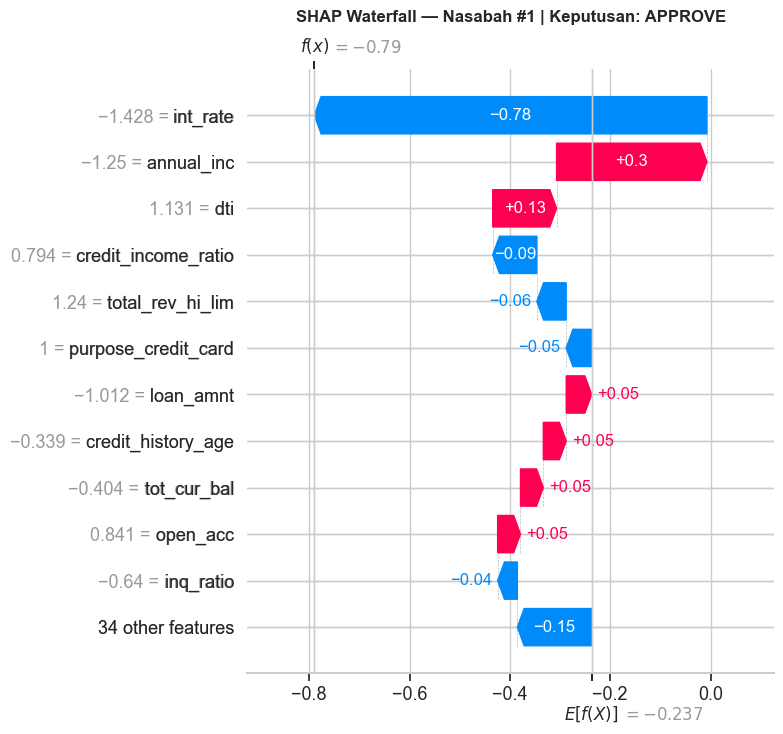


>>> PENJELASAN NASABAH LOW RISK (GOOD LOAN):
  CREDIT DECISION EXPLANATION — Nasabah #0
  Skor Risiko (Prob Default) : 0.5934
  Threshold                  : 0.41
  Keputusan                  : REJECT
  Label Aktual               : Good (0)

  Faktor yang MENINGKATKAN risiko default:
    • int_rate = 1.02  →  SHAP: +0.5536
    • inq_last_6mths = 2.06  →  SHAP: +0.1109
    • dti = 0.68  →  SHAP: +0.1065
    • open_acc = 0.84  →  SHAP: +0.0675
    • inq_ratio = 0.36  →  SHAP: +0.0601

  Faktor yang MENURUNKAN risiko default:
    • installment_income_ratio = -0.56  →  SHAP: -0.0933
    • annual_inc = 0.02  →  SHAP: -0.0564
    • credit_income_ratio = 1.41  →  SHAP: -0.0544
    • installment = -0.36  →  SHAP: -0.0479
    • tot_cur_bal = 1.13  →  SHAP: -0.0395


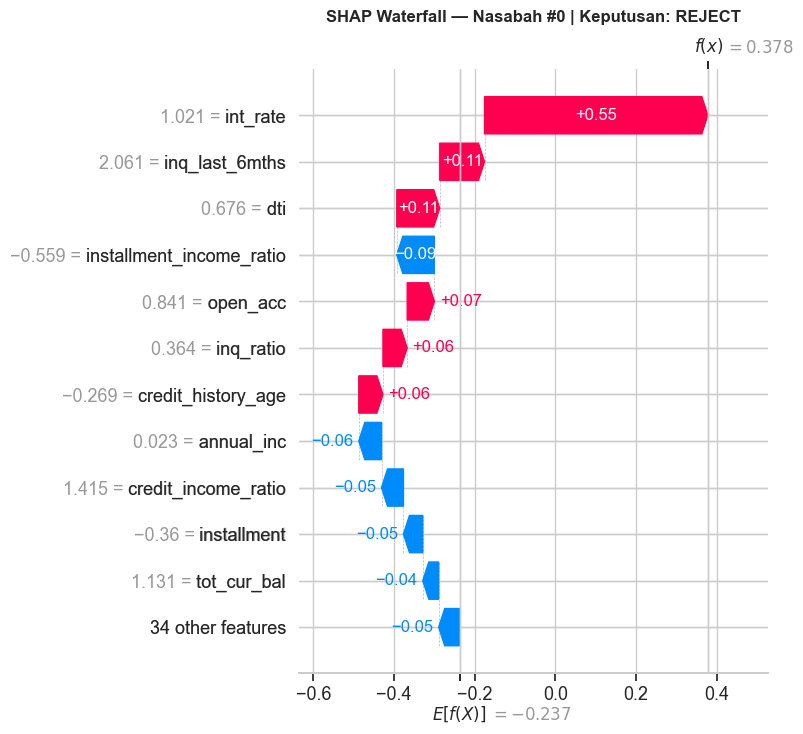

In [29]:
# Contoh: satu nasabah bad loan (reject) dan satu good loan (approve)
pos_bad  = X_test.index.get_loc(y_test[y_test == 1].index[0])
pos_good = X_test.index.get_loc(y_test[y_test == 0].index[0])
 
print('\n>>> PENJELASAN NASABAH HIGH RISK (BAD LOAN):')
explain_single_applicant(pos_bad)
 
print('\n>>> PENJELASAN NASABAH LOW RISK (GOOD LOAN):')
explain_single_applicant(pos_good)